1. Exploratory Data Analysis.

In [1]:
import pandas as pd #for dataframes
import matplotlib.pyplot as plt #for visualization
import seaborn as sns #

In [2]:
df = pd.read_csv("Churn_Modelling.csv")

In [3]:
# printing the shape of the dataframe
print(df.shape)

(10000, 14)


In [4]:
#printing the five first rows
print(df.head())

   RowNumber  CustomerId   Surname  CreditScore Geography  Gender  Age   
0          1    15634602  Hargrave          619    France  Female   42  \
1          2    15647311      Hill          608     Spain  Female   41   
2          3    15619304      Onio          502    France  Female   42   
3          4    15701354      Boni          699    France  Female   39   
4          5    15737888  Mitchell          850     Spain  Female   43   

   Tenure    Balance  NumOfProducts  HasCrCard  IsActiveMember   
0       2       0.00              1          1               1  \
1       1   83807.86              1          0               1   
2       8  159660.80              3          1               0   
3       1       0.00              2          0               0   
4       2  125510.82              1          1               1   

   EstimatedSalary  Exited  
0        101348.88       1  
1        112542.58       0  
2        113931.57       1  
3         93826.63       0  
4         790

In [5]:
# print the data type of each feature
print(df.dtypes)

RowNumber            int64
CustomerId           int64
Surname             object
CreditScore          int64
Geography           object
Gender              object
Age                  int64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard            int64
IsActiveMember       int64
EstimatedSalary    float64
Exited               int64
dtype: object


In [6]:
#check for missing values
print(df.isnull().sum())

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64


Exited
0    0.7963
1    0.2037
Name: proportion, dtype: float64


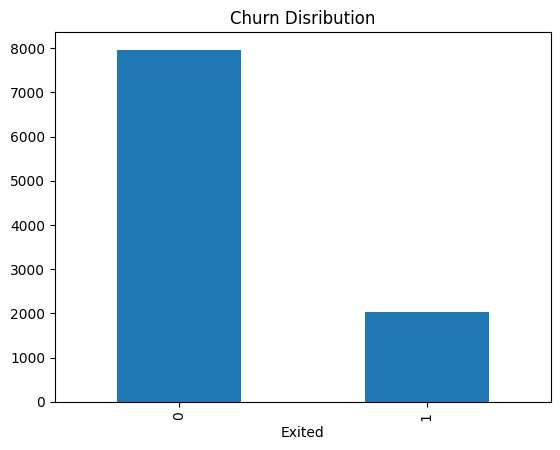

In [7]:
# Check for class inbalance
print(df["Exited"].value_counts(normalize=True))
df["Exited"].value_counts().plot(kind="bar")
plt.title("Churn Disribution")
plt.show()

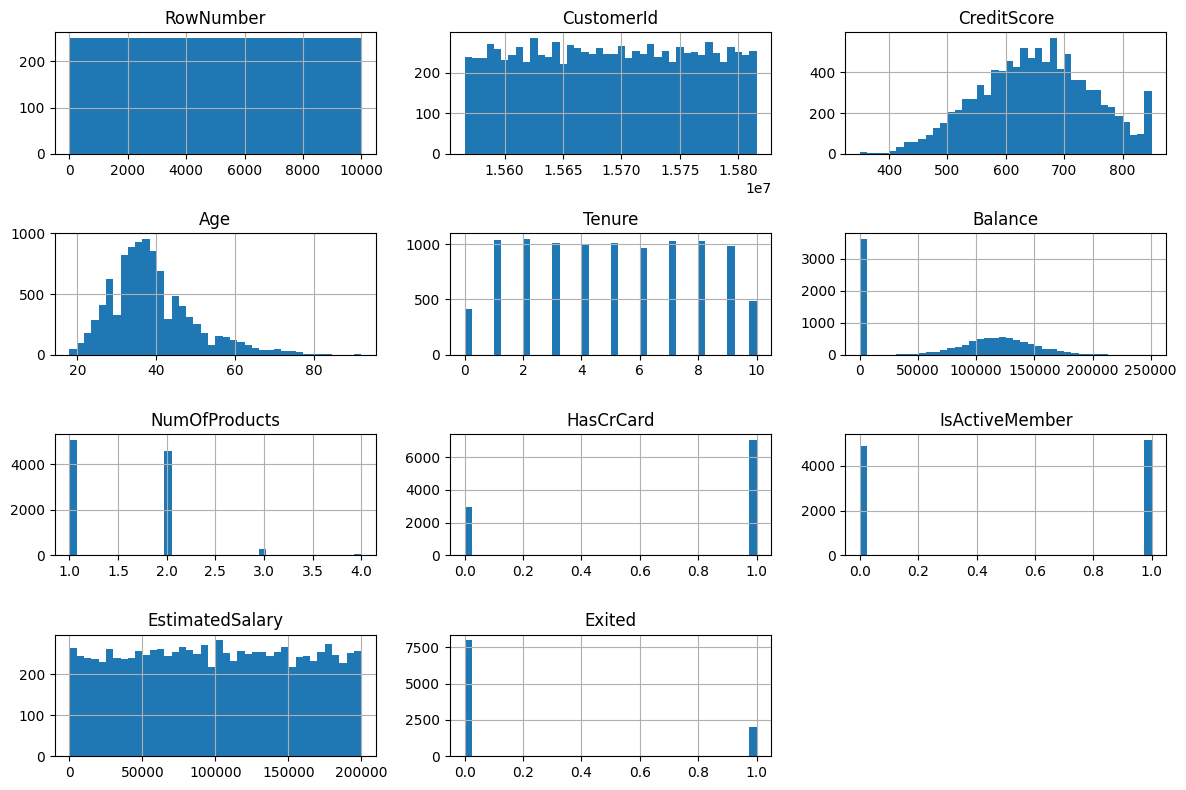

In [8]:
#numerical feature distribution
df.hist(figsize = (12, 8), bins = 40)
plt.tight_layout()
plt.show()

In [9]:
for col in ["Geography", "Gender", "NumOfProducts", "HasCrCard", "IsActiveMember"]:
    churn_rate = df.groupby(col)["Exited"].mean()
    print(churn_rate)

Geography
France     0.161548
Germany    0.324432
Spain      0.166734
Name: Exited, dtype: float64
Gender
Female    0.250715
Male      0.164559
Name: Exited, dtype: float64
NumOfProducts
1    0.277144
2    0.075817
3    0.827068
4    1.000000
Name: Exited, dtype: float64
HasCrCard
0    0.208149
1    0.201843
Name: Exited, dtype: float64
IsActiveMember
0    0.268509
1    0.142691
Name: Exited, dtype: float64


In [10]:
(df["NumOfProducts"] == 4).value_counts()

NumOfProducts
False    9940
True       60
Name: count, dtype: int64

2. Data Preprocessing

In [11]:
# dropping unnecessary columns
df = df.drop(columns=["RowNumber", "CustomerId", "Surname"])

In [12]:
# Encode categorical columns
df = pd.get_dummies(df, columns = ["Geography", "Gender"], drop_first = True)

In [13]:
# splitting X and Y
X = df.drop(columns = ["Exited"])
y = df["Exited"]

In [14]:
# Train test split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, stratify = y)

In [15]:
print(X_train.shape, X_test.shape)
print(y_train.shape, y_test.shape)

(8000, 11) (2000, 11)
(8000,) (2000,)


In [16]:
!pip install xgboost 

In [ ]:
# Training the XGBoost model and seeing how is the model at separating the two classes using AUC curve

from xgboost import XGBClassifier

neg = (y_train == 0).sum()
pos = (y_train == 1).sum()

scale = neg / pos
print(scale)

model = XGBClassifier(n_estimators = 100, learning_rate = 0.1, max_depth = 4, scale_pos_weight = scale, eval_metric = "auc", random_state = 42)

model.fit(X_train, y_train, eval_set = [(X_test, y_test)], verbose = 10)

3.9079754601226995
[0]	validation_0-auc:0.80868


[10]	validation_0-auc:0.85110
[20]	validation_0-auc:0.86009
[30]	validation_0-auc:0.86540
[40]	validation_0-auc:0.86811
[50]	validation_0-auc:0.86971
[60]	validation_0-auc:0.87082
[70]	validation_0-auc:0.87107
[80]	validation_0-auc:0.87205
[90]	validation_0-auc:0.87301
[99]	validation_0-auc:0.87307


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='auc', feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, num_parallel_tree=None, ...)

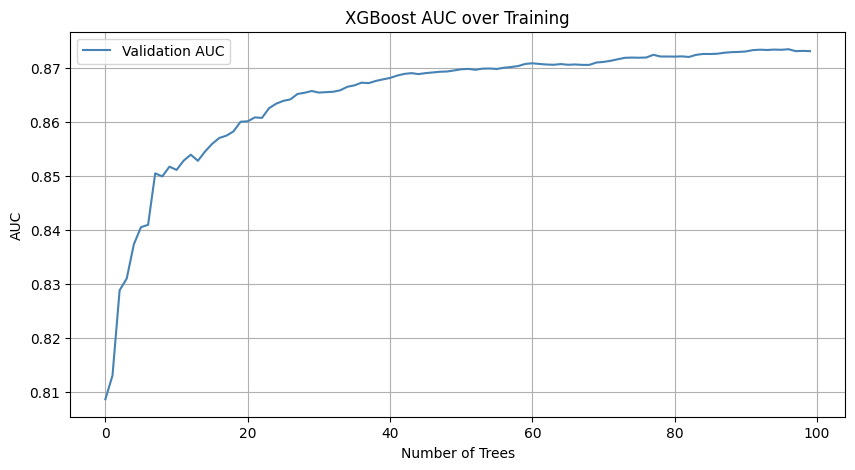

In [23]:
import matplotlib.pyplot as plt

# Get the evaluation results
results = model.evals_result()
auc_scores = results["validation_0"]["auc"]

# Plot
plt.figure(figsize=(10, 5))
plt.plot(auc_scores, label="Validation AUC", color="steelblue")
plt.xlabel("Number of Trees")
plt.ylabel("AUC")
plt.title("XGBoost AUC over Training")
plt.legend()
plt.grid(True)
plt.show()

              precision    recall  f1-score   support

           0       0.93      0.81      0.87      1593
           1       0.50      0.76      0.61       407

    accuracy                           0.80      2000
   macro avg       0.72      0.79      0.74      2000
weighted avg       0.84      0.80      0.81      2000



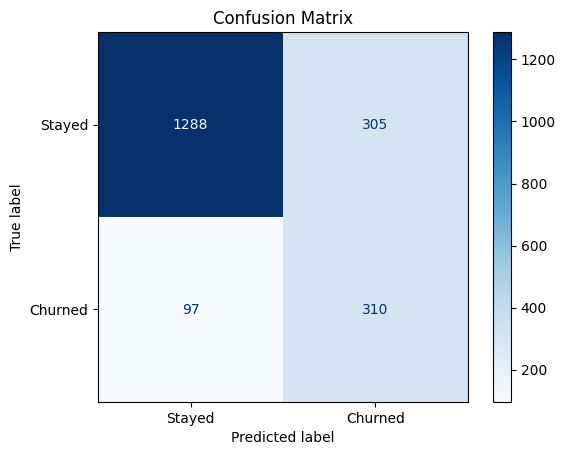

In [24]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = ["Stayed", "Churned"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

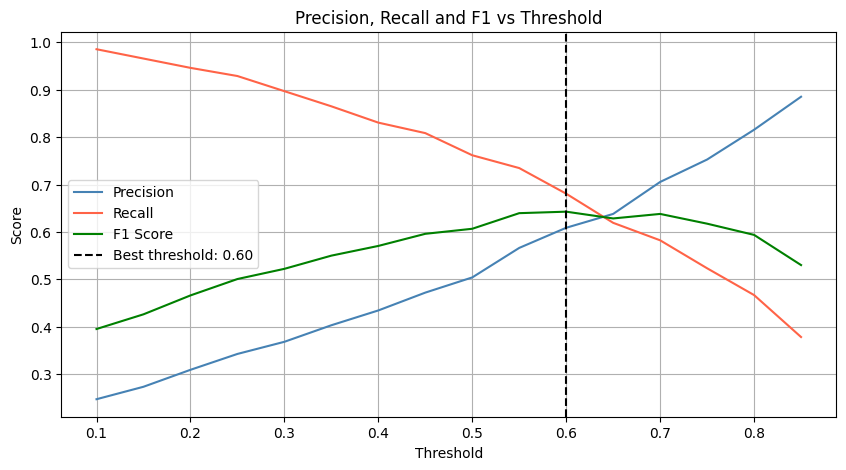

Best threshold (max F1): 0.60
Precision: 0.61
Recall:    0.68
F1:        0.64


In [25]:
from sklearn.metrics import precision_score, recall_score, f1_score
import numpy as np

# Test a range of thresholds
thresholds = np.arange(0.1, 0.9, 0.05)

precisions, recalls, f1s = [], [], []

for t in thresholds:
    y_pred_t = (y_pred_proba >= t).astype(int)
    precisions.append(precision_score(y_test, y_pred_t))
    recalls.append(recall_score(y_test, y_pred_t))
    f1s.append(f1_score(y_test, y_pred_t))

# Plot
plt.figure(figsize=(10, 5))
plt.plot(thresholds, precisions, label="Precision", color="steelblue")
plt.plot(thresholds, recalls, label="Recall", color="tomato")
plt.plot(thresholds, f1s, label="F1 Score", color="green")
plt.axvline(thresholds[np.argmax(f1s)], color="black", linestyle="--", label=f"Best threshold: {thresholds[np.argmax(f1s)]:.2f}")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision, Recall and F1 vs Threshold")
plt.legend()
plt.grid(True)
plt.show()

# Print best threshold
best_threshold = thresholds[np.argmax(f1s)]
print(f"Best threshold (max F1): {best_threshold:.2f}")
print(f"Precision: {precisions[np.argmax(f1s)]:.2f}")
print(f"Recall:    {recalls[np.argmax(f1s)]:.2f}")
print(f"F1:        {max(f1s):.2f}")

              precision    recall  f1-score   support

           0       0.92      0.89      0.90      1593
           1       0.61      0.68      0.64       407

    accuracy                           0.85      2000
   macro avg       0.76      0.78      0.77      2000
weighted avg       0.85      0.85      0.85      2000



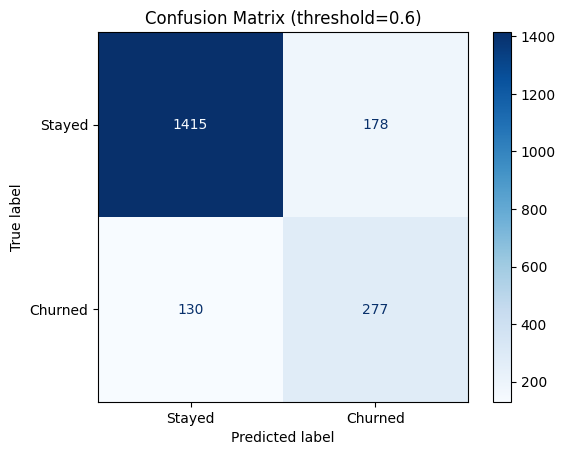

In [26]:
# Apply optimal threshold
best_threshold = 0.60
y_pred_final = (y_pred_proba >= best_threshold).astype(int)

# Final evaluation
print(classification_report(y_test, y_pred_final))

cm = confusion_matrix(y_test, y_pred_final)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Stayed", "Churned"])
disp.plot(cmap="Blues")
plt.title(f"Confusion Matrix (threshold={best_threshold})")
plt.show()

Best threshold for recall: 0.35
Precision: 0.40
Recall:    0.86


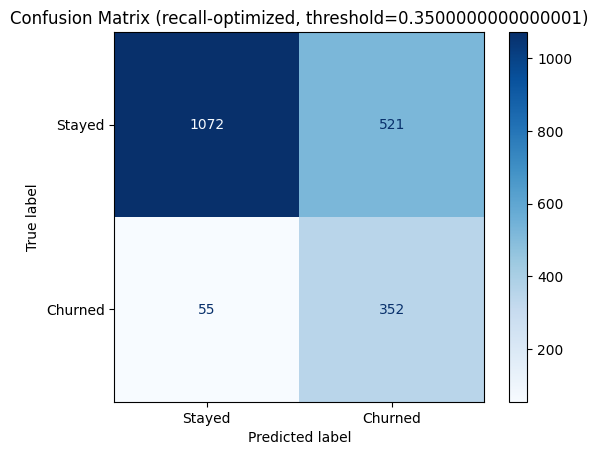

              precision    recall  f1-score   support

           0       0.95      0.67      0.79      1593
           1       0.40      0.86      0.55       407

    accuracy                           0.71      2000
   macro avg       0.68      0.77      0.67      2000
weighted avg       0.84      0.71      0.74      2000



In [27]:
# Find threshold that maximizes recall with precision >= 0.40
target_precision = 0.40

best_recall = 0
best_t = 0

for t, p, r in zip(thresholds, precisions, recalls):
    if p >= target_precision and r > best_recall:
        best_recall = r
        best_t = t

print(f"Best threshold for recall: {best_t:.2f}")
print(f"Precision: {precisions[list(thresholds).index(best_t)]:.2f}")
print(f"Recall:    {best_recall:.2f}")

# Apply it
y_pred_recall = (y_pred_proba >= best_t).astype(int)

cm = confusion_matrix(y_test, y_pred_recall)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Stayed", "Churned"])
disp.plot(cmap="Blues")
plt.title(f"Confusion Matrix (recall-optimized, threshold={best_t})")
plt.show()

print(classification_report(y_test, y_pred_recall))